In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('play_tennis.csv')
data.head()
data.drop(columns=['day'], inplace=True)

In [3]:
data.sample(5, random_state=42)

,outlook,temp,humidity,wind,play
9,Rain,Mild,Normal,Weak,Yes
11,Overcast,Mild,High,Strong,Yes
0,Sunny,Hot,High,Weak,No
12,Overcast,Hot,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No


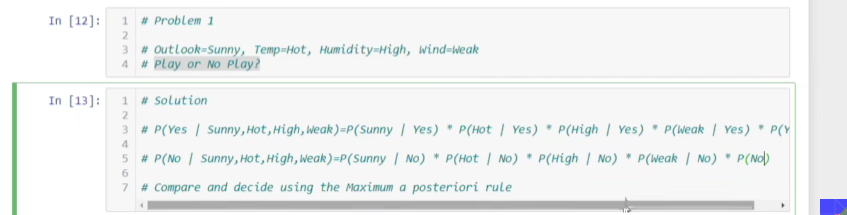

- But suppose the feature changes to some other input, so we need calculate the probabilities again.

- Thats why Naive Bayes while training makes a look up table of probabilities for each feature value given the class, so that it can quickly calculate the probabilities during prediction.

- First let's calculate P(Yes) and P(No) from the data as it is used the in most of the calculations

In [4]:
data['play'].value_counts()

play
Yes    9
No     5
Name: count, dtype: int64

In [5]:
p_yes = 9/14
p_no = 5/14

In [6]:
# Probabilities for Outlook

pd.crosstab(data['outlook'], data['play'])

play,No,Yes
outlook,,
Overcast,0,4
Rain,2,3
Sunny,3,2


In [7]:
P_Overcast_No = 0/5
P_Rainy_No = 2/5
P_Sunny_No = 3/4

P_Overcast_Yes = 4/9
P_Rainy_Yes = 3/9
P_Sunny_Yes = 2/9

# Temp probabilities

In [9]:
pd.crosstab(data['temp'], data['play'])

play,No,Yes
temp,,
Cool,1,3
Hot,2,2
Mild,2,4


In [10]:
P_Cool_No = 1/5
P_Hot_No = 2/5
P_Mild_No = 2/5

P_Cool_Yes = 3/9
P_Hot_Yes = 2/9
P_Mild_Yes = 4/9

## Humidity probabilities


In [11]:

pd.crosstab(data['humidity'], data['play'])

play,No,Yes
humidity,,
High,4,3
Normal,1,6


In [12]:
P_high_No = 4/5
P_normal_No = 1/5

P_high_Yes = 3/9
P_normal_Yes = 6/9

# Windy probabilities

In [13]:
pd.crosstab(data['wind'], data['play'])

play,No,Yes
wind,,
Strong,3,3
Weak,2,6


In [14]:
P_Strong_No = 3/5
P_Weak_No = 2/5

P_Strong_Yes = 3/9
P_Weak_Yes = 6/9

- Now we have all the probabilities we need to calculate the probability of play being yes or no given the input features.

- Let's predict for {outlook: sunny, temp: hot, humidity: high, windy: weak}

In [17]:
P_Yes_given_X = P_Sunny_Yes * P_Hot_Yes * P_high_Yes * P_Weak_Yes * p_yes
P_No_given_X = P_Sunny_No * P_Hot_No * P_high_No * P_Weak_No * p_no

In [18]:
print(f'P(Yes|X) = {P_Yes_given_X}')
print(f'P(No|X) = {P_No_given_X}')

P(Yes|X) = 0.007054673721340387
P(No|X) = 0.034285714285714294


- Hence, we can see that P(Yes|X) < P(No|X), so we predict play to be no for the given input features.